In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
import pandas as pd

In [ ]:
df_gob = pd.read_csv ('/content/Eleccion_gubernaturasB.csv')
df_gob.head()

,Estado,1992,1993,1995,1997,1998,2000,2001,2003,2004,2006,2007,2009,2010,2011,2012
0,Aguascalientes,6.53,NaN,NaN,NaN,8.82,NaN,NaN,NaN,6.83,NaN,NaN,NaN,7.22,NaN,NaN
1,Guanajuato,NaN,NaN,9.00,NaN,NaN,7.76,NaN,NaN,NaN,11.25,NaN,NaN,NaN,NaN,7.60
2,Jalisco,NaN,NaN,6.58,NaN,NaN,8.32,NaN,NaN,NaN,9.71,NaN,NaN,NaN,NaN,38.63
3,Michoacán,NaN,NaN,35.55,NaN,NaN,NaN,42.97,NaN,NaN,NaN,38.78,NaN,NaN,29.72,NaN
4,Querétaro,NaN,NaN,NaN,13.08,NaN,NaN,NaN,9.54,NaN,NaN,NaN,4.92,NaN,NaN,NaN


In [ ]:
df_gob.set_index('Estado', inplace=True)
df_gob.head()

,1992,1993,1995,1997,1998,2000,2001,2003,2004,2006,2007,2009,2010,2011,2012
Estado,,,,,,,,,,,,,,,
Aguascalientes,6.53,NaN,NaN,NaN,8.82,NaN,NaN,NaN,6.83,NaN,NaN,NaN,7.22,NaN,NaN
Guanajuato,NaN,NaN,9.00,NaN,NaN,7.76,NaN,NaN,NaN,11.25,NaN,NaN,NaN,NaN,7.60
Jalisco,NaN,NaN,6.58,NaN,NaN,8.32,NaN,NaN,NaN,9.71,NaN,NaN,NaN,NaN,38.63
Michoacán,NaN,NaN,35.55,NaN,NaN,NaN,42.97,NaN,NaN,NaN,38.78,NaN,NaN,29.72,NaN
Querétaro,NaN,NaN,NaN,13.08,NaN,NaN,NaN,9.54,NaN,NaN,NaN,4.92,NaN,NaN,NaN


In [ ]:
df_gob.index.name = None

In [ ]:
Año = list(map(str, range(1992, 2013)))
Año

['1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012']

In [ ]:
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt

In [ ]:
print(plt.style.available)
mpl.style.use(['ggplot'])

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


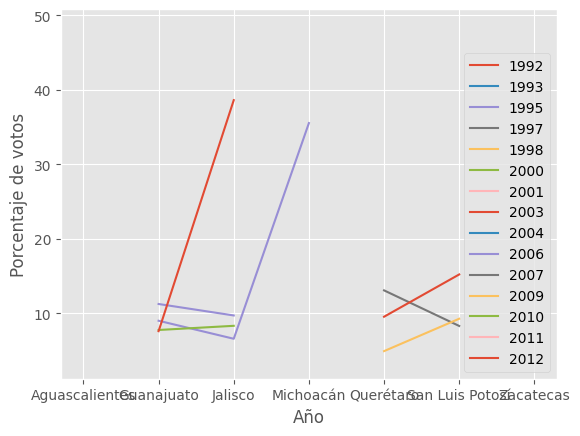

In [ ]:
df_gob.plot(kind='line')

plt.ylabel('Porcentaje de votos')
plt.xlabel('Año')

plt.show()

In [ ]:
df_gob = df_gob.transpose()
df_gob.head()

,Aguascalientes,Guanajuato,Jalisco,Michoacán,Querétaro,San Luis Potosí,Zacatecas
1992,6.53,NaN,NaN,NaN,NaN,NaN,NaN
1993,NaN,NaN,NaN,NaN,NaN,3.47,NaN
1995,NaN,9.0,6.58,35.55,NaN,NaN,NaN
1997,NaN,NaN,NaN,NaN,13.08,8.30,NaN
1998,8.82,NaN,NaN,NaN,NaN,NaN,48.6


In [ ]:
df_gob.index = df_gob.index.map(str)

In [ ]:
df_gob_interpolated = df_gob.interpolate(method='linear')

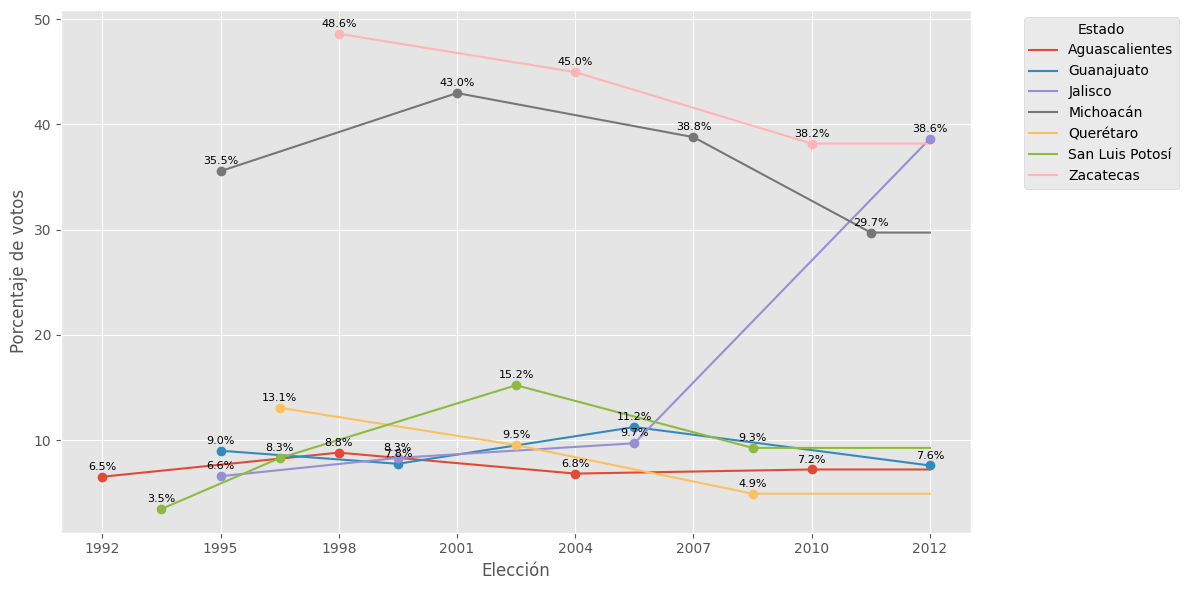

In [ ]:
plt.figure(figsize=(12, 6))
ax = df_gob_interpolated.plot(kind='line', linestyle='-', ax=plt.gca())

for column in df_gob.columns:
    ax.plot(df_gob.index, df_gob[column], 'o')

    for i, y in enumerate(df_gob[column]):
        if not pd.isna(y):  # Solo agregar etiquetas en puntos con datos
            ax.annotate(f'{y:.1f}%', (df_gob.index[i], y), textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

plt.ylabel('Porcentaje de votos')
plt.xlabel('Elección')
plt.legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')
plt.show()